In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import urllib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    silhouette_score
)



In [1]:
# Loading dataset from Kaggle
import pandas as pd

df = pd.read_csv(r"D:\UWS STUDIES\Term 2 Final Year Project\Project Chapters\Guide\Implementation\AutomotiveProject\ML Car Diagnostic Agent AI Assistant.csv")

# checking for first ten (15) rows
df.head(15)

,Record ID,Car Name,Problem Classification,Problem Description,Severity,Diagnosis,How to Fix the Problem,Solution Used,ECU Data,Service History,Repair Status,Results
0,1,Honda Civic 2019,Electrical,Headlights flicker,Medium,Loose wiring,Check and repair loose or damaged wiring conne...,Check and repair wiring,NaN,Spark plugs replaced 2 years ago,Fixed,Resolved
1,2,Toyota Corolla 2018,Electrical,Power window failure,Medium,Window regulator motor,Check and repair loose or damaged wiring conne...,Check and repair wiring,Multiple codes,Spark plugs replaced 2 years ago,Fixed,Resolved
2,3,BMW i4 2019,Engine,Engine misfire,High,Timing belt failure,Replace spark plugs,Replaced failure,P0101,Regular maintenance,Fixed,Resolved
3,4,Nissan Rogue 2020,Transmission,Transmission overheating,High,Transmission fluid thick,Perform transmission service and inspect for i...,Perform transmission service,NaN,Spark plugs replaced 2 years ago,Fixed,Resolved
4,5,Mercedes S-Class 2020,Battery,Battery drains fast,High,Dead battery,Replace battery and test charging system,Replaced battery,NaN,Brake service 1 year ago,Fixed,Resolved
5,6,Nissan Murano 2022,Transmission,Slipping gears,Medium,Transmission fluid thick,Replace transmission fluid,Replaced thick,Multiple codes,Regular maintenance,Fixed,Resolved
6,7,Ford Bronco 2018,Electrical,Car wont start,Low,Dead battery,Replace alternator and test battery condition,Repair in progress,Multiple codes,Brake service 1 year ago,In Progress,Monitoring
7,8,Kia Sportage 2018,Engine,Engine overheating,High,Timing belt failure,Replace spark plugs,Replaced failure,Multiple codes,Coolant flush last year,Fixed,Resolved
8,9,BMW X7 2022,Electrical,Battery drains fast,Low,Loose wiring,Secure and repair connections,Secure and repair connections,P0400,Spark plugs replaced 2 years ago,Fixed,Resolved
9,10,Nissan Frontier 2018,Electrical,Power window failure,Low,Dead battery,Check and repair loose or damaged wiring conne...,Check and repair wiring,NaN,Oil changed 6 months ago,Fixed,Resolved


In [2]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Record ID               10000 non-null  int64 
 1   Car Name                10000 non-null  object
 2   Problem Classification  10000 non-null  object
 3   Problem Description     10000 non-null  object
 4   Severity                10000 non-null  object
 5   Diagnosis               10000 non-null  object
 6   How to Fix the Problem  10000 non-null  object
 7   Solution Used           10000 non-null  object
 8   ECU Data                6680 non-null   object
 9   Service History         8688 non-null   object
 10  Repair Status           10000 non-null  object
 11  Results                 10000 non-null  object
dtypes: int64(1), object(11)
memory usage: 937.6+ KB


Record ID                    0
Car Name                     0
Problem Classification       0
Problem Description          0
Severity                     0
Diagnosis                    0
How to Fix the Problem       0
Solution Used                0
ECU Data                  3320
Service History           1312
Repair Status                0
Results                      0
dtype: int64

In [3]:
# Data Preprocessing
# Split Car Name into Brand, Year and Model

df[['CarBrand', 'Remainder']] = df['Car Name'].str.split(' ',n=1, expand=True)
df['ManufactureYear'] = df['Car Name'].str.extract(r'(\d{4})').astype(int)
df['CarModel'] = df['Remainder'].str.replace(r'\s*\d{4}', '', regex=True).str.strip()

# Vehicle Age column
import datetime
current_year = datetime.datetime.now().year
df['VehicleAge'] = current_year - df['ManufactureYear']

# Map Severity to numbers
severity_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['SeverityEncoded'] = df['Severity'].map(severity_map)

# Binary target variable for repair success
df['RepairSuccess'] = (df['Repair Status'] == 'Fixed').astype(int)

# ECU Data indicator (1 = has code, 0 = none)
df['HasECU'] = df['ECU Data'].apply(lambda x: 0 if str(x).strip().lower() == 'none' else 1)

# Map Diagnoses to Parts Categories
parts_map = {
    'Dead battery': 'Battery', 'Faulty alternator': 'Battery',
    'Starter motor failure': 'Battery', 'Charging system fault': 'Battery',
    'Worn pads': 'Brake Components', 'Low brake fluid': 'Brake Components',
    'Warped rotors': 'Brake Components', 'Worn master cylinder': 'Brake Components',
    'Worn brake pads': 'Brake Components',
    'Timing belt failure': 'Engine Components', 'Spark plug wear': 'Engine Components',
    'Ignition coil failure': 'Engine Components', 'Fuel pump issue': 'Engine Components',
    'Transmission fluid thick': 'Transmission Fluid', 
    'Transmission fluid low': 'Transmission Fluid',
    'Transmission solenoid': 'Transmission Parts', 'Clutch pack wear': 'Transmission Parts',
    'Transmission wear': 'Transmission Parts',
    'Loose wiring': 'Electrical Components', 'Wiring issue': 'Electrical Components',
    'Window regulator motor': 'Electrical Components'
}
df['PartsCategory'] = df['Diagnosis'].map(parts_map).fillna('Other')

# Check result
print(df[['Car Name','CarBrand','CarModel','ManufactureYear','VehicleAge',
          'SeverityEncoded','RepairSuccess','HasECU','PartsCategory']].head(5))


                Car Name  CarBrand CarModel  ManufactureYear  VehicleAge  \
0       Honda Civic 2019     Honda    Civic             2019           7   
1    Toyota Corolla 2018    Toyota  Corolla             2018           8   
2            BMW i4 2019       BMW       i4             2019           7   
3      Nissan Rogue 2020    Nissan    Rogue             2020           6   
4  Mercedes S-Class 2020  Mercedes  S-Class             2020           6   

   SeverityEncoded  RepairSuccess  HasECU          PartsCategory  
0                2              1       1  Electrical Components  
1                2              1       1  Electrical Components  
2                3              1       1      Engine Components  
3                3              1       1     Transmission Fluid  
4                3              1       1                Battery  


In [8]:
%pip install sqlalchemy pyodbc

Note: you may need to restart the kernel to use updated packages.
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 4.4.0
    Uninstalling typing-extensions-4.4.0:


You should consider upgrading via the 'C:\Users\slade\AppData\Local\Programs\MUEDIT~1\Python\pythonw.exe -m pip install --upgrade pip' command.


      Successfully uninstalled typing-extensions-4.4.0


In [4]:
from sqlalchemy import create_engine
import urllib
# Connect to SQL Server
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=MRCARLOS\SQLEXPRESS;"
    "DATABASE=AutomotiveServiceDB;"
    "Trusted_Connection=yes;"
)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# load Vehicles table
vehicles_df = df[['CarBrand','CarModel','ManufactureYear']].drop_duplicates().reset_index(drop=True)
vehicles_df.insert(0, 'CarName', df['Car Name'].drop_duplicates().reset_index(drop=True))
vehicles_df.to_sql('Vehicles', engine, if_exists='append', index=False)

print("Vehicles loaded:", len(vehicles_df), "rows")


Vehicles loaded: 810 rows


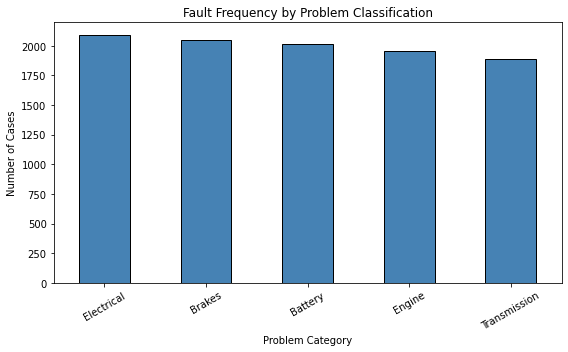

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
# Visualisation: Fault distribution chart
plt.figure(figsize=(8,5))
df['Problem Classification'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Fault Frequency by Problem Classification')
plt.xlabel('Problem Category')
plt.ylabel('Number of Cases')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig1_fault_classification.png', dpi=150)
plt.show()


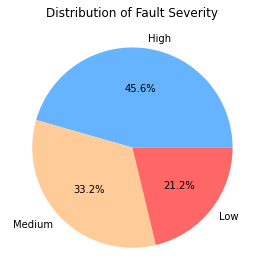

In [6]:
# Severity distribution
plt.figure(figsize=(6,4))
df['Severity'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
colors=['#66b3ff','#ffcc99','#ff6666'])
plt.title('Distribution of Fault Severity')
plt.ylabel('')
plt.tight_layout()
plt.savefig('fig2_severity_distribution.png', dpi=150)
plt.show()



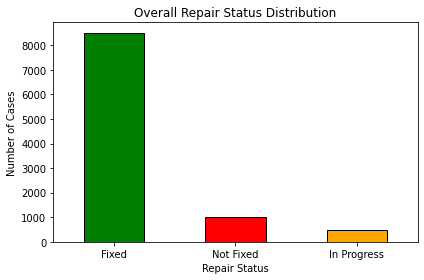

In [7]:
# Visualisation: Repair success rates by severity
plt.figure(figsize=(6,4))
df['Repair Status'].value_counts().plot(kind='bar', color=['green','red','orange'], edgecolor='black')
plt.title('Overall Repair Status Distribution')
plt.xlabel('Repair Status')
plt.ylabel('Number of Cases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig3_repair_status.png', dpi=150)
plt.show()


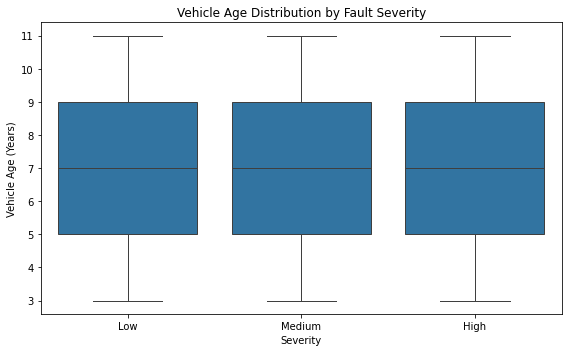

In [8]:
# Vehicle Age vs Fault Severity
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Severity',
    y='VehicleAge',
    order=['Low', 'Medium', 'High']
)
plt.title('Vehicle Age Distribution by Fault Severity')
plt.xlabel('Severity')
plt.ylabel('Vehicle Age (Years)')
plt.tight_layout()
plt.savefig('fig4_age_vs_severity.png', dpi=150)
plt.show()


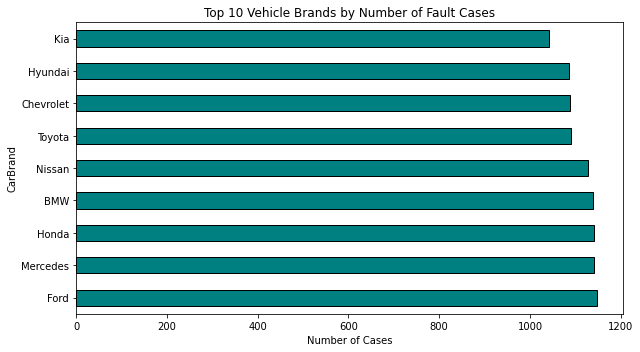

In [9]:
#Top 10 Brands by fault count
plt.figure(figsize=(9,5))
df['CarBrand'].value_counts().head(10).plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Vehicle Brands by Number of Fault Cases')
plt.xlabel('Number of Cases')
plt.tight_layout()
plt.savefig('fig5_brand_faults.png', dpi=150)
plt.show()


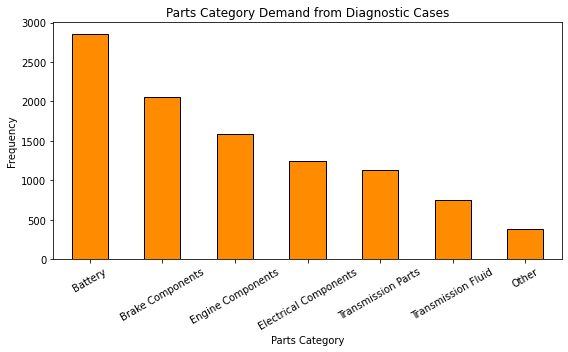

In [10]:
# Parts categories demand
plt.figure(figsize=(8,5))
df['PartsCategory'].value_counts().plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Parts Category Demand from Diagnostic Cases')
plt.xlabel('Parts Category')
plt.ylabel('Frequency')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig6_parts_demand.png', dpi=150)
plt.show()


In [13]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.

You should consider upgrading via the 'C:\Users\slade\AppData\Local\Programs\MUEDIT~1\Python\pythonw.exe -m pip install --upgrade pip' command.


In [11]:
# Now we will prepare data for machine learning models
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
le_brand   = LabelEncoder()
le_problem = LabelEncoder()
le_parts   = LabelEncoder()

df['BrandEncoded']   = le_brand.fit_transform(df['CarBrand'])
df['ProblemEncoded'] = le_problem.fit_transform(df['Problem Classification'])
df['PartsEncoded']   = le_parts.fit_transform(df['PartsCategory'])

# Define features (X) and target (y)
features = ['BrandEncoded', 'ProblemEncoded', 'SeverityEncoded',
            'VehicleAge', 'HasECU', 'PartsEncoded']

X = df[features]
y = df['RepairSuccess']  # This shows 1 = Fixed, 0 = Not Fixed 

print("Features shape:", X.shape)
print("Target value counts:\n", y.value_counts())


Features shape: (10000, 6)
Target value counts:
 RepairSuccess
1    8504
0    1496
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)
import numpy as np

# Split data into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape :", X_train.shape)
print("Test set shape     :", X_test.shape)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced"   
)
rf_model.fit(X_train, y_train)

# To evaluate the model on the test set
y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

# 5-Fold Cross Validation (F1-score)
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
print("5-Fold CV F1 Scores:", np.round(cv_scores, 3))
print("Mean CV F1:", round(cv_scores.mean(), 3))


Training set shape : (8000, 6)
Test set shape     : (2000, 6)
=== Random Forest Results ===
              precision    recall  f1-score   support

           0      0.125     0.237     0.163       299
           1      0.841     0.707     0.768      1701

    accuracy                          0.636      2000
   macro avg      0.483     0.472     0.466      2000
weighted avg      0.734     0.636     0.677      2000

ROC-AUC: 0.476
5-Fold CV F1 Scores: [0.779 0.778 0.763 0.785 0.782]
Mean CV F1: 0.777


In [14]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

# Standardise features for logistic regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)
y_pred_lr  = lr_model.predict(X_test_sc)
y_proba_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr, digits=3, zero_division=0))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 3))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       299
           1      0.851     1.000     0.919      1701

    accuracy                          0.851      2000
   macro avg      0.425     0.500     0.460      2000
weighted avg      0.723     0.851     0.782      2000

ROC-AUC: 0.49


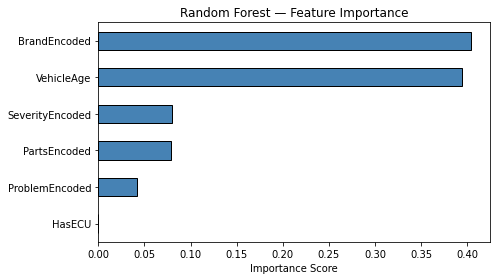

In [15]:
# Feature importance chart for Random Forest
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=features)
importances.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black',
    figsize=(7, 4)
)

plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig7_feature_importance.png', dpi=150)
plt.show()


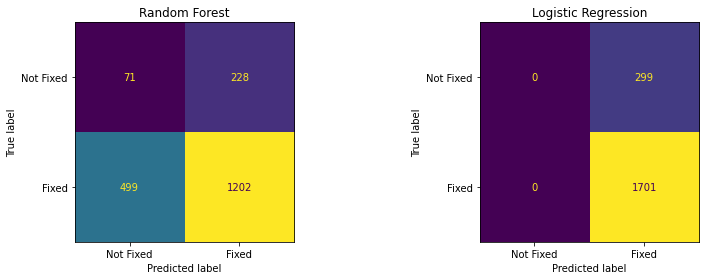

In [16]:
# confusion matrix (Visualisation)
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Random Forest confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Fixed', 'Fixed'],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('Random Forest')

# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Not Fixed', 'Fixed'],
    ax=axes[1],
    colorbar=False
)
axes[1].set_title('Logistic Regression')

plt.tight_layout()
plt.savefig('fig8_confusion_matrices.png', dpi=150)
plt.show()


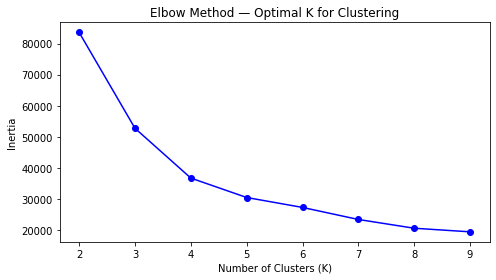

Silhouette Score (K=4): 0.399
         SeverityEncoded  VehicleAge
Cluster                             
0                   1.97        9.48
1                   2.68        5.00
2                   2.00        5.03
3                   2.64        9.55


In [17]:
# K-Means Clustering (Fault Segmentation)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = ['SeverityEncoded', 'ProblemEncoded', 'VehicleAge', 'PartsEncoded']
X_cluster = df[cluster_features]

# Elbow Method — This finds the best number of clusters
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K for Clustering')
plt.tight_layout()
plt.savefig('fig9_elbow_method.png', dpi=150)
plt.show()

# Apply K = 4 (or whatever the elbow suggests)
best_k = 4
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_cluster)

sil_score = silhouette_score(X_cluster, df['Cluster'])
print(f"Silhouette Score (K={best_k}):", round(sil_score, 3))

# Show cluster profile
print(
    df.groupby('Cluster')[['SeverityEncoded', 'VehicleAge']]
      .mean()
      .round(2)
)


In [2]:
%pip install streamlit

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'C:\Users\slade\AppData\Local\Programs\MUEDIT~1\Python\pythonw.exe -m pip install --upgrade pip' command.
